# Matriz de sobras: Shadow Matrix

Proceso para construir la matriz de sombra

1. Identificar todos los valores faltantes

2. Remplazar los valores faltantes con True (1) y el resto con false (0)

3. Remplazar los True y False por algo que sea mas informativo. Agregar un sufijo a los nombres de las variables

Despues de tener todo separado ya podriamos fusionar la tabla original con la nueva tabla y a esta nueva matriz se le conoce como (***Nabular***)

Y queda perfecto para realizar la matriz de valores faltantes

In [36]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src.pandas_accessors import MissingMethods
from src.data_loader import load_all_datasets

datasets = load_all_datasets()

riskfactors = datasets['riskfactors']

## Construccion de la matriz de sobras

Aca estamos aplicando los pasos de la introduccion. 

Aprovechando que ya los valores faltantes de este dataset ya estan normalizados y por lo tanto lo podemos identificar de una manera sencilla nos permite saltar esta parte de tranformacion de datos faltantes diversos (-99, -1, "N/A) a valores reconocidos por la libreria de pandas a su vez no tenemos valores implicitos que tengamos que convertir a explicitos

Por lo que los pasos que seguimos son los siguientes

- Identificar valores faltantes (isna()) nos devuelve la matriz con False donde hay datos y True donde no existen datos
- ahora los remplazamos a algo mucho mas facil de identificar con .replace() indicando que valor queremos para cada casilla
- Agregamos el sufijo _NA para que al final de los encabezados identifiquemos que estos hacen alucion a los valores faltantes
- Por ultimo aprovechamos la funcion anonima para concatenar ambas matrices y poder graficar de manera adecuada segun las necesidades que tengamos

In [11]:
(
    riskfactors
    .isna()
    .replace({
        False: "Not Missing",
        True: "Missing"
    })
    .add_suffix("_NA")
    .pipe(
        lambda shadow_matrix: pd.concat(
            [riskfactors, shadow_matrix], 
            axis="columns"
        )
    )
)

,state,sex,age,weight_lbs,height_inch,bmi,marital,pregnant,children,education,...,smoke_100_NA,smoke_days_NA,smoke_stop_NA,smoke_last_NA,diet_fruit_NA,diet_salad_NA,diet_potato_NA,diet_carrot_NA,diet_vegetable_NA,diet_juice_NA
0,26,Female,49,190,64,32.68,Married,NaN,0,6,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
1,40,Female,48,170,68,25.90,Divorced,NaN,0,5,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
2,72,Female,55,163,64,28.04,Married,NaN,0,4,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
3,42,Male,42,230,74,29.59,Married,NaN,1,6,...,Not Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing
4,32,Female,66,135,62,24.74,Widowed,NaN,0,5,...,Not Missing,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,10,Female,79,144,63,25.56,Widowed,NaN,0,4,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
241,46,Male,45,170,74,21.87,Divorced,NaN,2,4,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
242,15,Male,62,175,71,24.46,Divorced,NaN,0,6,...,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
243,34,Female,62,138,64,23.74,Married,NaN,0,4,...,Not Missing,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing


### Utilizar funcion de utileria bind_shadow_matrix()

Es exactamente lo que aplicamos en la segmentacion de arriba pero con una extencion que hicimos a la libreria de pandas para que solo sea llamar la funcion

De esta manera abstraemos el concepto para aplicarlo a cualquier conjunto de datos que tengamos en cualquier momento

In [13]:
(
    riskfactors
    .missing
    .bind_shadow_matrix(only_missing=True)
)

,state,sex,age,weight_lbs,height_inch,bmi,marital,pregnant,children,education,...,smoke_100_NA,smoke_days_NA,smoke_stop_NA,smoke_last_NA,diet_fruit_NA,diet_salad_NA,diet_potato_NA,diet_carrot_NA,diet_vegetable_NA,diet_juice_NA
0,26,Female,49,190,64,32.68,Married,NaN,0,6,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
1,40,Female,48,170,68,25.90,Divorced,NaN,0,5,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
2,72,Female,55,163,64,28.04,Married,NaN,0,4,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
3,42,Male,42,230,74,29.59,Married,NaN,1,6,...,Not Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing
4,32,Female,66,135,62,24.74,Widowed,NaN,0,5,...,Not Missing,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,10,Female,79,144,63,25.56,Widowed,NaN,0,4,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
241,46,Male,45,170,74,21.87,Divorced,NaN,2,4,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
242,15,Male,62,175,71,24.46,Divorced,NaN,0,6,...,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
243,34,Female,62,138,64,23.74,Married,NaN,0,4,...,Not Missing,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing


### Explorar estadisticos utilizando las nuevas columnas de la matriz de sobra

In [21]:
(
    riskfactors
    .missing.bind_shadow_matrix(only_missing=True)
    .groupby(["weight_lbs_NA"])
    ["age"]
    .describe()
    .reset_index()
)

,weight_lbs_NA,count,mean,std,min,25%,50%,75%,max
0,Missing,10.0,60.100000,13.706851,37.0,52.25,62.5,65.0,82.0
1,Not Missing,235.0,58.021277,17.662904,7.0,47.50,59.0,70.0,97.0


## Visualizacion de valores faltantes en una variable

### 1. Estructura y Ejes del Gráfico

* **Eje Y (`age`):** Representa la distribución de la edad para ambos grupos (escala continua de 0 a 100 años).
* **Eje X (`weight_lbs_NA`):** Clasifica a la población evaluada según la presencia o ausencia del registro de peso:
  * **`Not Missing` (Izquierda):** Registros que cuentan con la información de peso.
  * **`Missing` (Derecha):** Registros con datos faltantes en la variable de peso.

El ancho de cada nivel rectangular indica la densidad poblacional en ese rango específico de edad.

---

### 2. Análisis por Grupos

#### Grupo de la Izquierda (`Not Missing`)
* **Rango de mayor densidad:** El rango con mayor concentración de personas con peso registrado se ubica aproximadamente entre los **48 y 70 años** (representado por el rectángulo de mayor anchura).
* **Mediana:** La mediana de edad para este grupo ronda los **59–60 años**.

#### Grupo de la Derecha (`Missing`)
* **Rango principal:** Las personas a las que no se les registró el peso tienen sus edades concentradas mayoritariamente entre los **52 y 65 años**. *(Nota: Esto indica la distribución de edad dentro del conjunto de datos faltantes, no una franja excluyente).*
* **Mediana:** La mediana de edad del grupo sin dato de peso se sitúa ligeramente por encima de los **62 años**.
* **Valores atípicos (Outliers):** Los puntos individuales distribuidos fuera del bloque central representan registros atípicos dentro del grupo faltante (edades aproximadas de **~37, ~43, ~50, ~75 y ~82 años**).

---

### 3. Conclusión del Análisis de Datos

La distribución de la edad entre ambos grupos presenta un comportamiento homogéneo:

* Las personas con datos faltantes de peso registran una mediana de edad levemente superior (**~62 años** frente a **~59 años** en el grupo con datos completos).
* La ausencia de datos de peso se concentra fundamentalmente en el rango de adultos maduros y mayores (**50–65 años**).
* La omisión del dato de peso no evidencia un sesgo hacia extremos poblacionales (ni muy jóvenes ni muy ancianos), manteniéndose alineada con la estructura demográfica general de la muestra.

<Axes: xlabel='weight_lbs_NA', ylabel='age'>

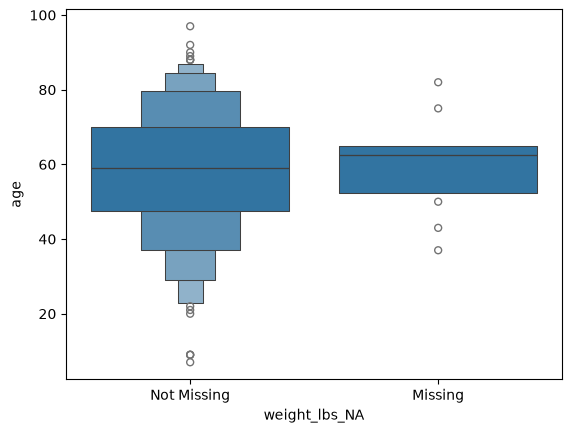

In [24]:
(
    riskfactors
    .missing.bind_shadow_matrix(only_missing=True)
    .pipe(
        lambda df: (
            sns.boxenplot(data=df, x="weight_lbs_NA", y="age")
        )
    )
)

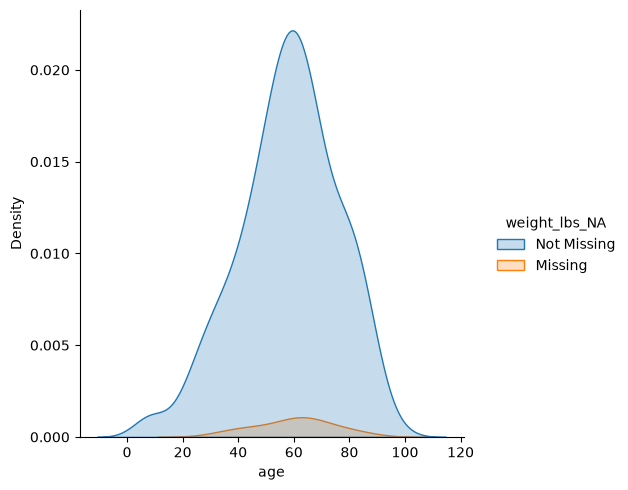

In [26]:
(
    riskfactors
    .missing.bind_shadow_matrix(only_missing=True)
    .pipe(
        lambda df: (
            sns.displot(
                data=df, 
                x="age", 
                hue="weight_lbs_NA", 
                kind="kde",
                fill=True
            )
        )
    )
)

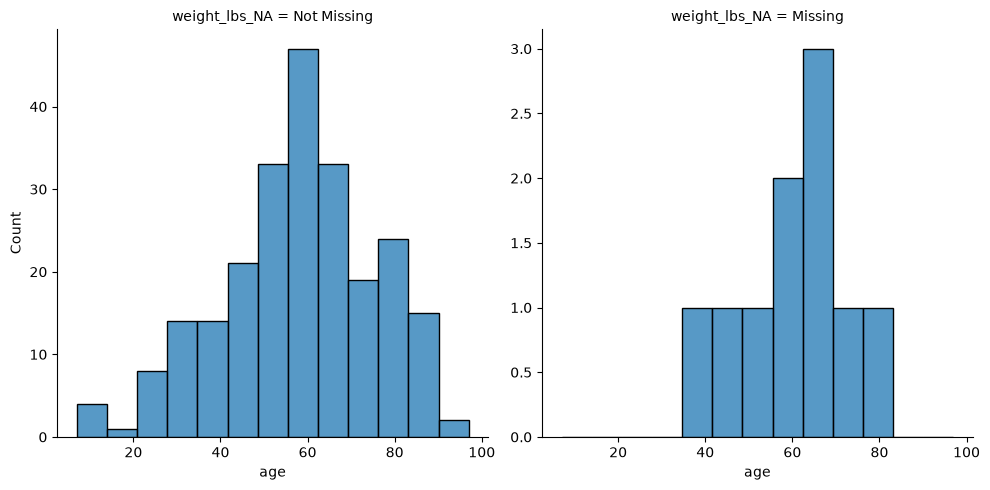

In [29]:
(
    riskfactors
    .missing.bind_shadow_matrix(only_missing=True)
    .pipe(
        lambda df: (
            sns.displot(
                data=df, 
                x="age", 
                col="weight_lbs_NA", 
                facet_kws={"sharey": False},
                fill=True
            )
        )
    )
)

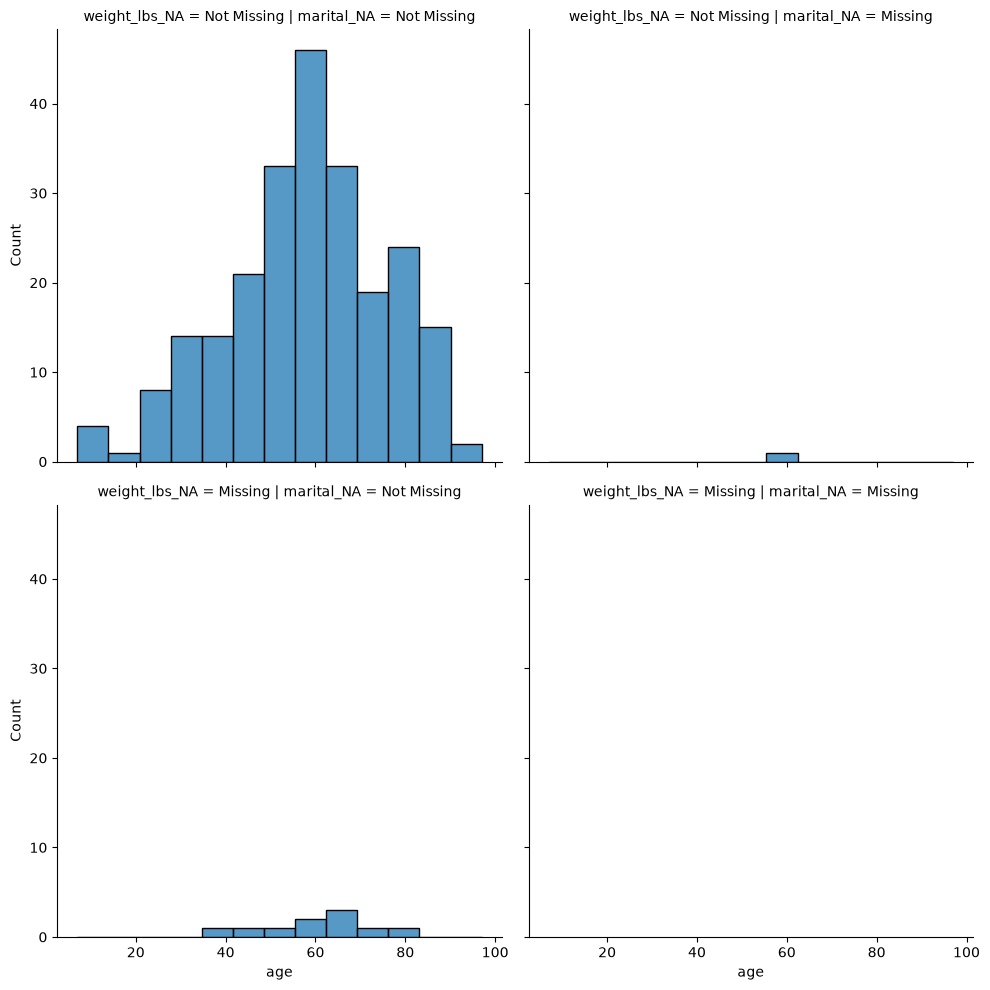

In [30]:
(
    riskfactors
    .missing.bind_shadow_matrix(only_missing=True)
    .pipe(
        lambda df: (
            sns.displot(
                data=df, 
                x="age", 
                col="marital_NA", 
                row="weight_lbs_NA"
            )
        )
    )
)

### Comparación de Métodos de Visualización (EDA)

* **`boxenplot` (Resumen Estadístico Robusto):**
  * **Pregunta clave:** *"¿En qué punto central se concentran los datos y cuáles son los límites estadísticos de la distribución?"*
  * **Utilidad:** Entrega métricas puntuales (mediana, cuartiles, deciles) y resalta inmediatamente observaciones atípicas. Ideal para reportes que requieren resúmenes de posición y dispersión.
* **`displot(kind="kde")` (Morfología de la Distribución):**
  * **Pregunta clave:** *"¿Cómo fluye la frecuencia de los datos a lo largo de la variable continua y dónde se dan las modas o crestas?"*
  * **Utilidad:** Revela la forma exacta de la masa de datos. Permite identificar picos máximos (modas), puntos de inflexión (cambios de tendencia) y multimodalidad (subgrupos).

---

### Cuadro Comparativo

| Característica | `boxenplot` | `displot(kind="kde")` |
| :--- | :--- | :--- |
| **Punto fuerte** | Identificar la mediana y comparar variabilidad / *outliers*. | Identificar el pico máximo (moda) y la forma de la curva. |
| **Interpretación** | Basada en intervalos discretos (bloques de cuartiles). | Basada en una función continua de densidad. |
| **Riesgo visual** | Oculta si la distribución tiene múltiples picos dentro del mismo bloque. | Puede suavizar demasiado los datos si el *bandwidth* es alto. |

Ambas visualizaciones resultan complementarias durante el Análisis Exploratorio de Datos (EDA): `kde` facilita la comprensión del comportamiento del fenómeno, mientras que `boxenplot` respalda las decisiones de limpieza o imputación con base en rangos numéricos.

## Visualizacion de valores faltantes en dos variables

#### Explicación de la Función `column_fill_with_dummies`

Esta función resuelve la limitación del `scatterplot` (que descarta automáticamente los registros con `np.nan`) mediante la imputación sintética de valores nulos fuera del rango real de datos, aplicando una técnica de dispersión aleatoria (*jittering*).

---

#### 1. Protección de Datos y Detección de Nulos

* **Copia de seguridad:** Utiliza `column.copy(deep=True)` para evitar la modificación de la serie original en el DataFrame.
* **Cálculo de metadatos:** 
  * Genera una máscara booleana (`missing_mask`) para identificar las posiciones `NaN`.
  * Calcula la cantidad total de valores faltantes (`number_missing_values`).
  * Determina la amplitud de la variable (`column_range = max - min`), parámetro base para escalar el desplazamiento y el ruido.

---

#### 2. Relocalización de Datos Faltantes (`column_shift`)

* **Ubicación sintética:** Desplaza los valores nulos por debajo del mínimo real observatorio mediante la fórmula:
  $$\text{column\_shift} = \text{min} - (\text{min} \times \text{proportion\_below})$$
* **Propósito:** Crea una zona virtual "por debajo del suelo" para agrupar los datos faltantes sin interferir con la distribución real de la variable.

---

#### 3. Aplicación de Dispersión Aleatoria (`column_jitter`)

* **Prevención del traslape:** Si todos los nulos se asignaran al valor fijo de `column_shift`, colapsarían en un único punto superpuesto.
* **Mecanismo:** 
  * Fija la semilla aleatoria (`np.random.seed(seed)`) para garantizar reproducibilidad.
  * Genera un ruido proporcional al rango de los datos y al factor de dispersión:
    $$\text{column\_jitter} = (\text{rand} - 2) \times \text{column\_range} \times \text{jitter}$$
  * Esparce los puntos nulos en forma de "nube" visible alrededor de la coordenada desplazada.

---

#### 4. Sustitución y Visualización Resultante

* **Asignación:** Reemplaza los registros faltantes en la serie con la suma del desplazamiento base y la dispersión (`column_shift + column_jitter`).
* **Efecto en el Scatterplot:** Al aplicar este tratamiento a dos variables ($X$ e $Y$), la gráfica permite analizar cuatro cuadrantes:
  * **Región central:** Registros con datos válidos en $X$ e $Y$.
  * **Franja inferior:** Datos presentes en $X$, pero faltantes en $Y$.
  * **Franja izquierda:** Datos presentes en $Y$, pero faltantes en $X$.
  * **Esquina inferior izquierda:** Datos faltantes de forma simultánea en $X$ e $Y$.

In [37]:
def column_fill_with_dummies(
    column: pd.Series,
    proportion_below: float= 0.10,
    jitter: float = 0.075,
    seed:  int = 42
) -> pd.Series:
    column = column.copy(deep=True)

    #Extraer valores de los metadatos
    missing_mask = column.isna()
    number_missing_values = missing_mask.sum()
    column_range = column.max() - column.min()

    #Cambio de datos
    column_shift = column.min() - column.min() * proportion_below

    # Crear el ruido alrededor de los puntos
    np.random.seed(seed)
    column_jitter = (np.random.rand(number_missing_values) - 2) * column_range * jitter

    # Guardando nuevo conjunto de datos
    column[missing_mask] = column_shift + column_jitter

    return column


#### Explicación del Pipeline para la Visualización de Nulos con Scatterplot

Este bloque de código integra la imputación sintética de valores faltantes dentro de un pipeline metódico usando Pandas y Seaborn, permitiendo graficar los registros incompletos junto a los datos válidos.

---

#### 1. Filtrado de Columnas con Faltantes

* **Filtro numérico:** Utiliza `select_dtypes(exclude="category")` para trabajar únicamente con variables continuas.
* **Selección de columnas incompletas:** A través de `.pipe(lambda df: df[df.columns[df.isna().any()]])`, selecciona únicamente las columnas que contienen al menos un valor `NaN`.

---

#### 2. Creación de Matriz de Sombras y Aplicación de Dummies

* **Matriz de sombras:** `.missing.bind_shadow_matrix(...)` duplica las columnas existentes creando una contraparte booleana (con sufijo `_NA`) para rastrear explícitamente qué registros son nulos (`True`) y cuáles no (`False`).
* **Transformación condicional:** Mediante `.apply(...)`, evalúa cada columna:
  * Si la columna es una sombra booleana (`_NA` en el nombre), la mantiene intacta.
  * Si es una variable numérica original, ejecuta la función `column_fill_with_dummies()`, desplazando sus `NaN` un 5% por debajo del mínimo (`proportion_below=0.05`) con un nivel de ruido del 7.5% (`jitter=0.075`).

---

#### 3. Creación del Indicador de Nulidad Combinada

* **Creación de `nullity`:** Utiliza `.assign(nullity = lambda df: df.weight_lbs_NA | df.height_inch_NA)` aplicando el operador OR lógico (`|`).
* **Propósito:** Genera una columna booleana que devuelve `True` si a la observación le falta **al menos una** de las dos variables analizadas (`weight_lbs` o `height_inch`), sirviendo como categoría de agrupamiento visual.

---

#### 4. Generación del Scatterplot

* **Visualización:** Pasa el DataFrame procesado a `sns.scatterplot(...)`.
* **Mapeo de color (`hue="nullity"`):** Diferencia visualmente con colores distintos los registros que tienen información completa de aquellos que sufren de nulidad en al menos una variable.
* **Efecto final:** El gráfico despliega los datos reales al centro y las combinaciones de valores faltantes agrupadas en las franjas artificiales (inferior e izquierda) y en la esquina inferior izquierda.

<Axes: xlabel='weight_lbs', ylabel='height_inch'>

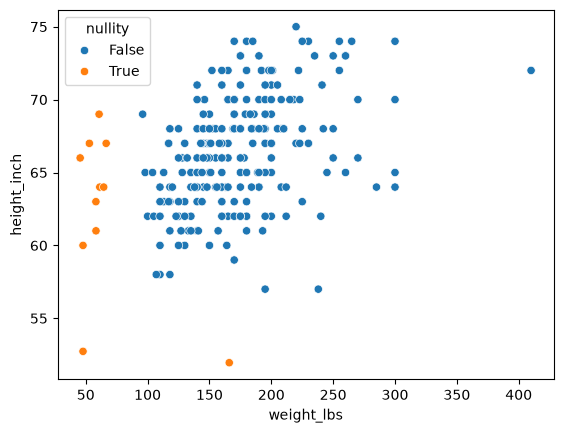

In [45]:
(
    riskfactors
    .select_dtypes(
        exclude="category"
    )
    .pipe(
        lambda df: df[df.columns[df.isna().any()]]
    )
    .missing.bind_shadow_matrix(true_string = True, false_string = False)
    .apply(
        lambda column: column if "_NA" in column.name else column_fill_with_dummies(
            column, 
            proportion_below=0.05, 
            jitter=0.075
        )
    )
    .assign(
       nullity = lambda df: df.weight_lbs_NA | df.height_inch_NA
    )
    .pipe(
        lambda df: (
            sns.scatterplot(
                data = df,
                x = "weight_lbs",
                y = "height_inch",
                hue = "nullity",
            )
        )
    )

)

## Correlacion de nulidad

<Axes: >

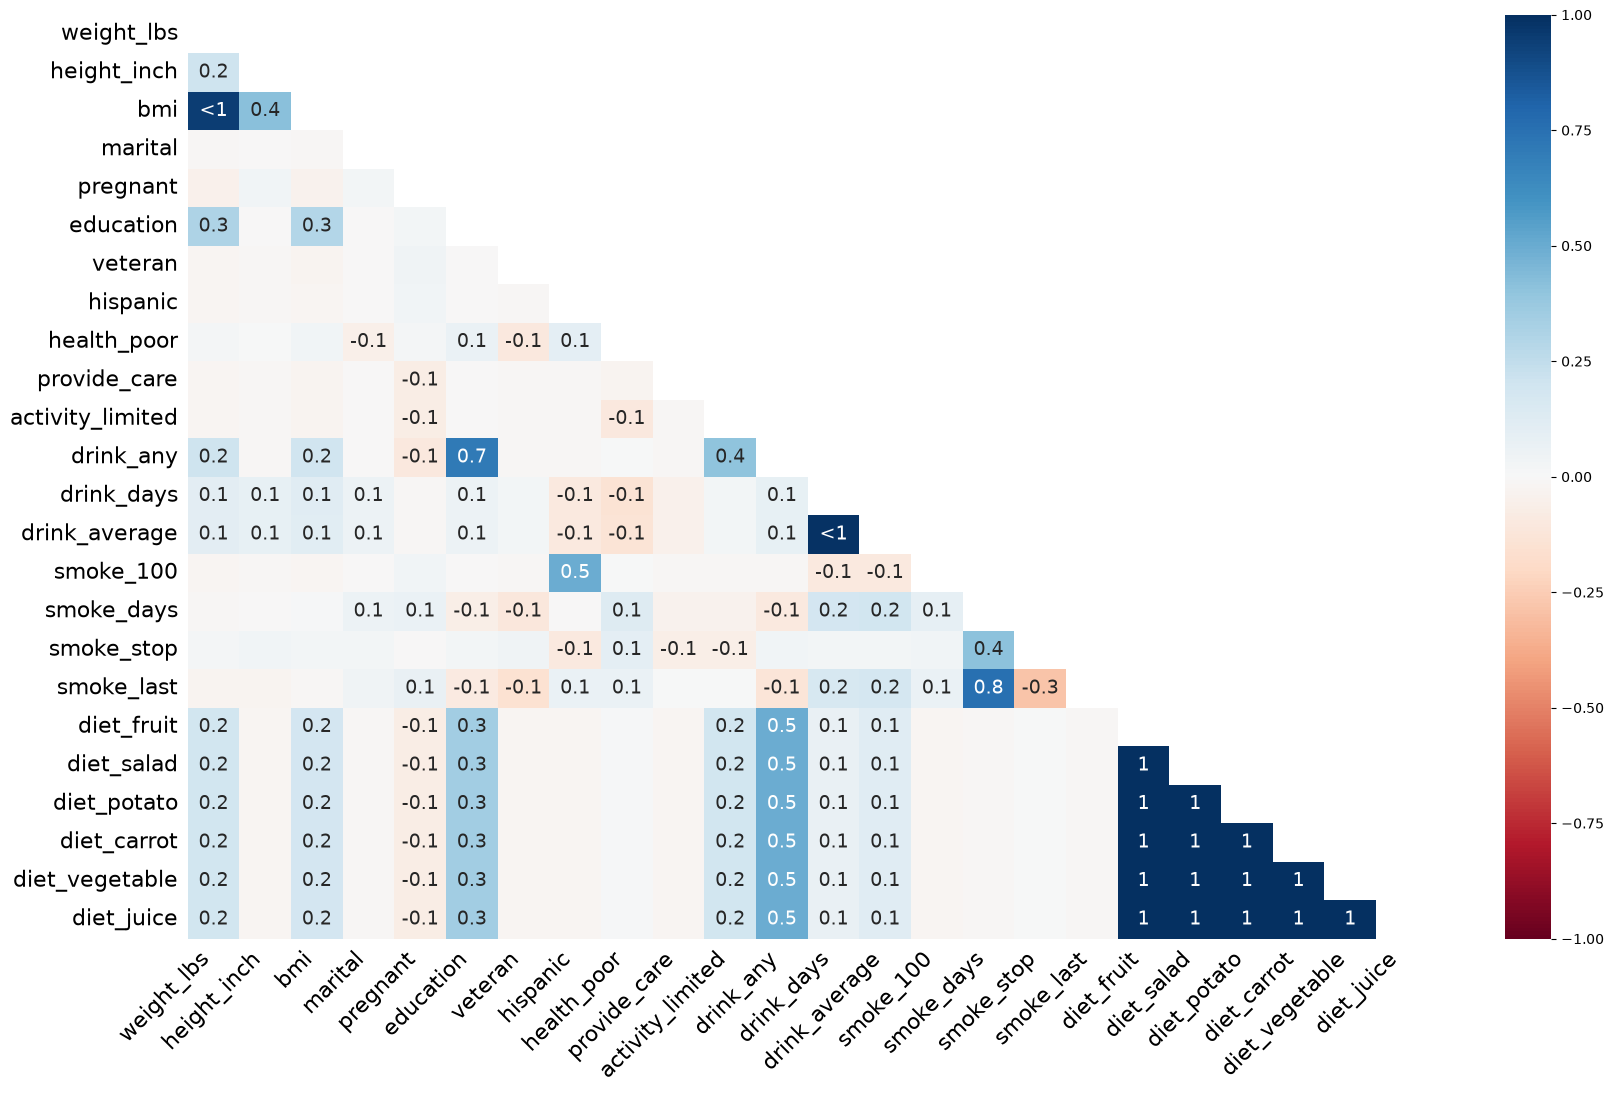

In [46]:
msno.heatmap(
    df= riskfactors
)

<Axes: >

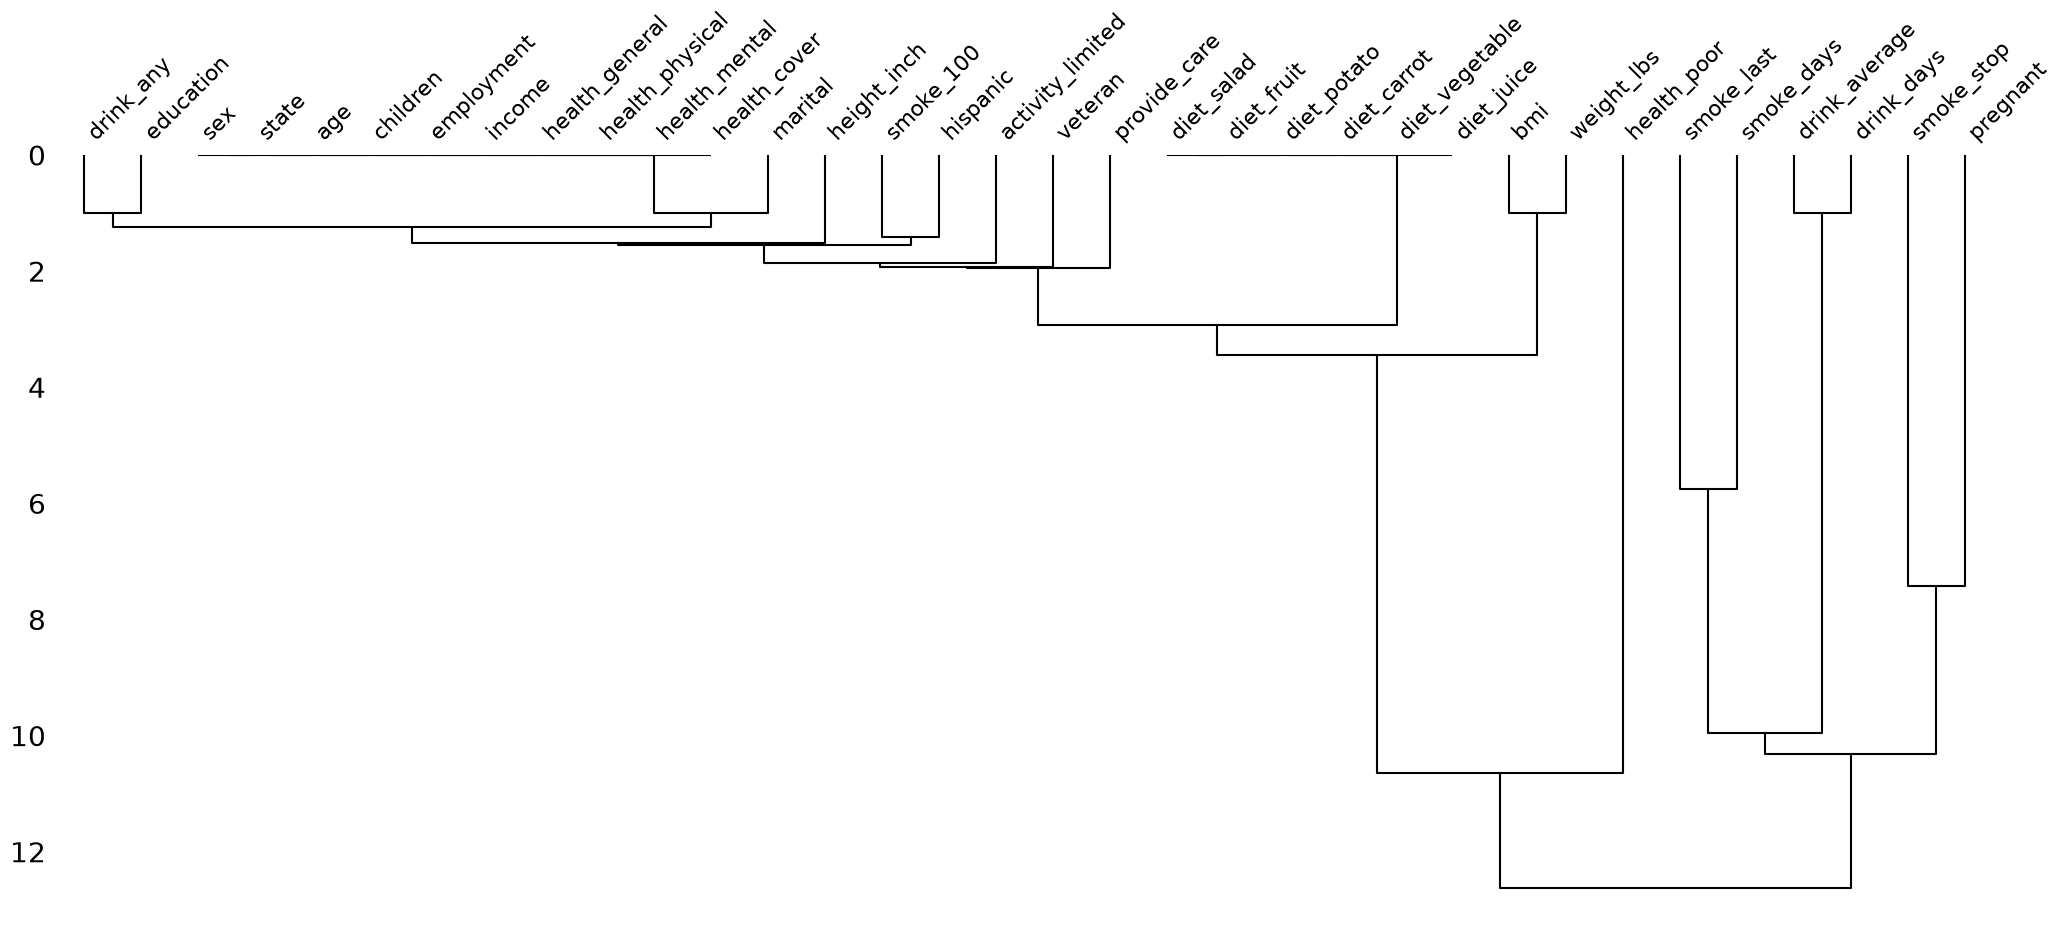

In [47]:
msno.dendrogram(
    df= riskfactors
)